# Feature Selection and Correlation Analysis for NO₂ Forecasting

This notebook documents the feature selection process for the Utrecht NO₂ forecasting model.  
We go from raw API data to a clean, reduced feature set that will be used for sequence models (e.g. LSTMs).

**Steps:**
1. Environment Setup and loading raw weather and air quality data.
2. Inspect missing values.
3. Explore feature distributions.
4. Analyse correlations.
5. Explore temporal patterns (hourly and daily).
6. Detect and interpret outliers.


### 1. Environment Setup and loading raw weather and air quality data

In [1]:
import yaml
import os
from pathlib import Path
import pandas as pd

os.chdir(Path.cwd().parent)
from src.data.api_requests import fetch_weather_data, fetch_air_quality_data
from src.data.analysis import (assess_missing_data, plot_missing_heatmap,
                               summarize_distributions, plot_histograms,
                               compute_correlation_matrix, plot_correlation_heatmap,
                               correlations_with_target,
                               diurnal_profile, weekly_profile,
                               detect_outliers_zscore, detect_outliers_iqr)


In [2]:

# download raw data based on config
with open("config.yaml", "r") as f:
    cfg = yaml.safe_load(f)
    
    
fetch_weather_data(cfg)
fetch_air_quality_data(cfg)

[WEATHER] Fetching utrecht (52.0908, 5.1222) from 2016-01-01 to 2024-12-31
[WEATHER] Saved 78912 rows to data/raw/weather/utrecht_weather_2016-01-01_to_2024-12-31.csv
[AIR] Fetching utrecht (52.0908, 5.1222) from 2016-01-01 to 2024-12-31
[AIR] Saved 78912 rows to data/raw/air_quality/utrecht_air_quality_2016-01-01_to_2024-12-31.csv


In [3]:
loc = list(cfg["api_requests"]["locations"].keys())[0]
start_date = cfg["api_requests"]["time"]["start_date"]
end_date = cfg["api_requests"]["time"]["end_date"]
# Load joined or per-source data
aq = pd.read_csv(f"data/raw/air_quality/{loc}_air_quality_{start_date}_to_{end_date}.csv", parse_dates=["time"])
wx = pd.read_csv(f"data/raw/weather/{loc}_weather_{start_date}_to_{end_date}.csv", parse_dates=["time"])

df = pd.merge(wx, aq, on=["time", "location"], how="inner")
assert len(df) == len(wx) == len(aq), "Rows were dropped during merge!"

### 2. Inspect missing values

The columns carbon_dioxide, methane, uv_index, uv_index_clear_sky, aerosol_optical_depth, and ammonia were dropped due to excessive missing values (up to 98%). The dataset start year was set to 2016 to ensure complete coverage for key pollutants like carbon monoxide and sulphur dioxide.

=== Missing data summary (sorted by missing_pct) ===
                                        dtype  n_missing  missing_pct
methane                               float64      77305        97.96
carbon_dioxide                        float64      77305        97.96
uv_index_clear_sky                    float64      57769        73.21
uv_index                              float64      57769        73.21
aerosol_optical_depth                 float64      57769        73.21
ammonia                               float64      17545        22.23
soil_moisture_100_to_255cm            float64          0         0.00
soil_temperature_7_to_28cm            float64          0         0.00
soil_temperature_28_to_100cm          float64          0         0.00
soil_temperature_100_to_255cm         float64          0         0.00
soil_moisture_0_to_7cm                float64          0         0.00
soil_moisture_7_to_28cm               float64          0         0.00
soil_moisture_28_to_100cm            

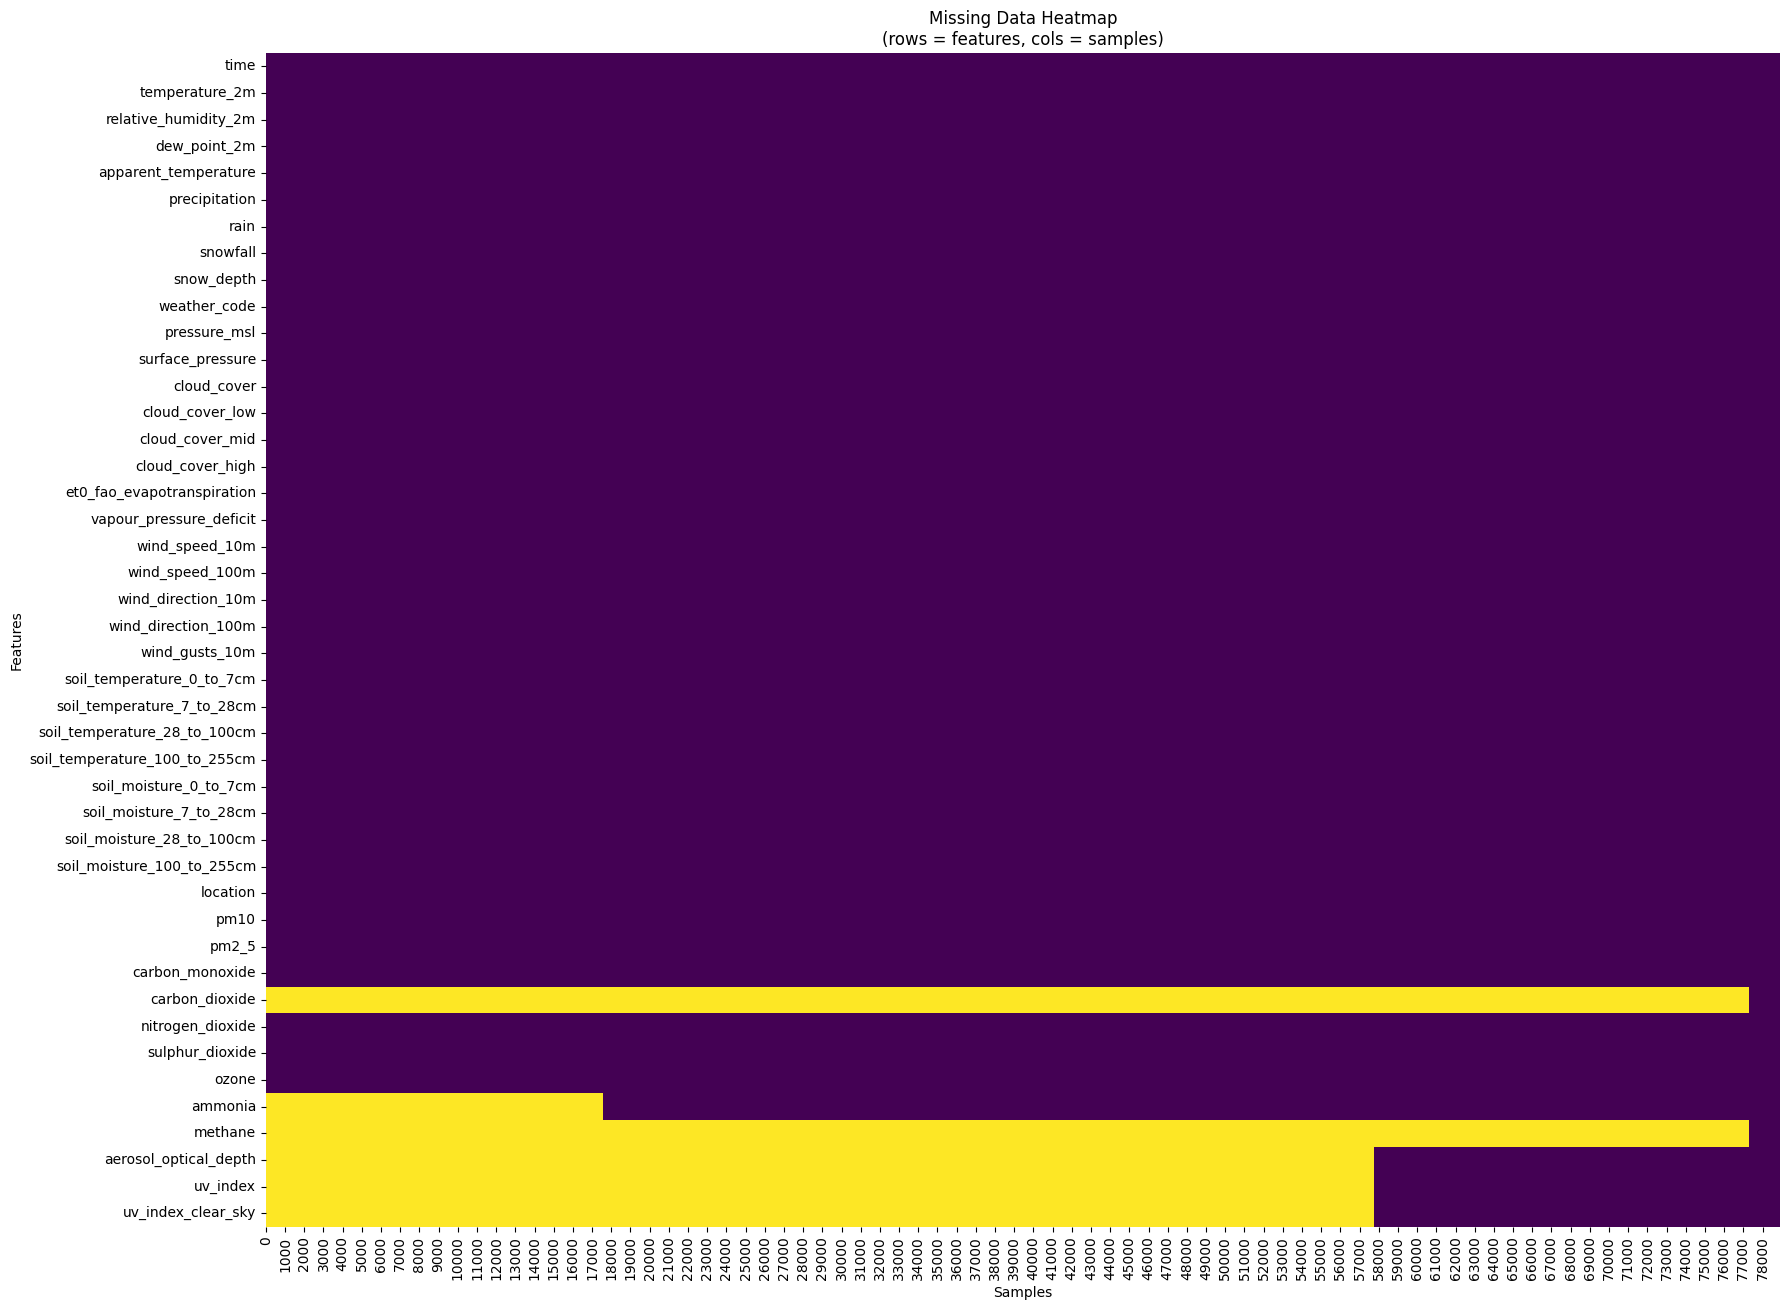

In [4]:
missing_summary = assess_missing_data(df)
plot_missing_heatmap(df)

### 3. Explore feature distributions.

Snow data is extremely rare in this dataset and is unlikely to provide meaningful predictive value. All other features appear acceptable; although some are heavily skewed, but this is not an issue for an LSTM-based model.

=== Distribution summary (numeric columns) ===
                                 count         mean         std       min  \
temperature_2m                 78912.0    11.167462    6.581672   -11.100   
relative_humidity_2m           78912.0    79.934002   13.842670    25.000   
dew_point_2m                   78912.0     7.537421    5.610521   -18.400   
apparent_temperature           78912.0     8.658829    8.034201   -16.200   
precipitation                  78912.0     0.102675    0.375920     0.000   
rain                           78912.0     0.099681    0.370126     0.000   
snowfall                       78912.0     0.002098    0.038702     0.000   
snow_depth                     78912.0     0.000958    0.008372     0.000   
weather_code                   78912.0    12.669594   21.054665     0.000   
pressure_msl                   78912.0  1015.297867   10.433732   968.600   
surface_pressure               78912.0  1014.080317   10.416974   967.400   
cloud_cover                  

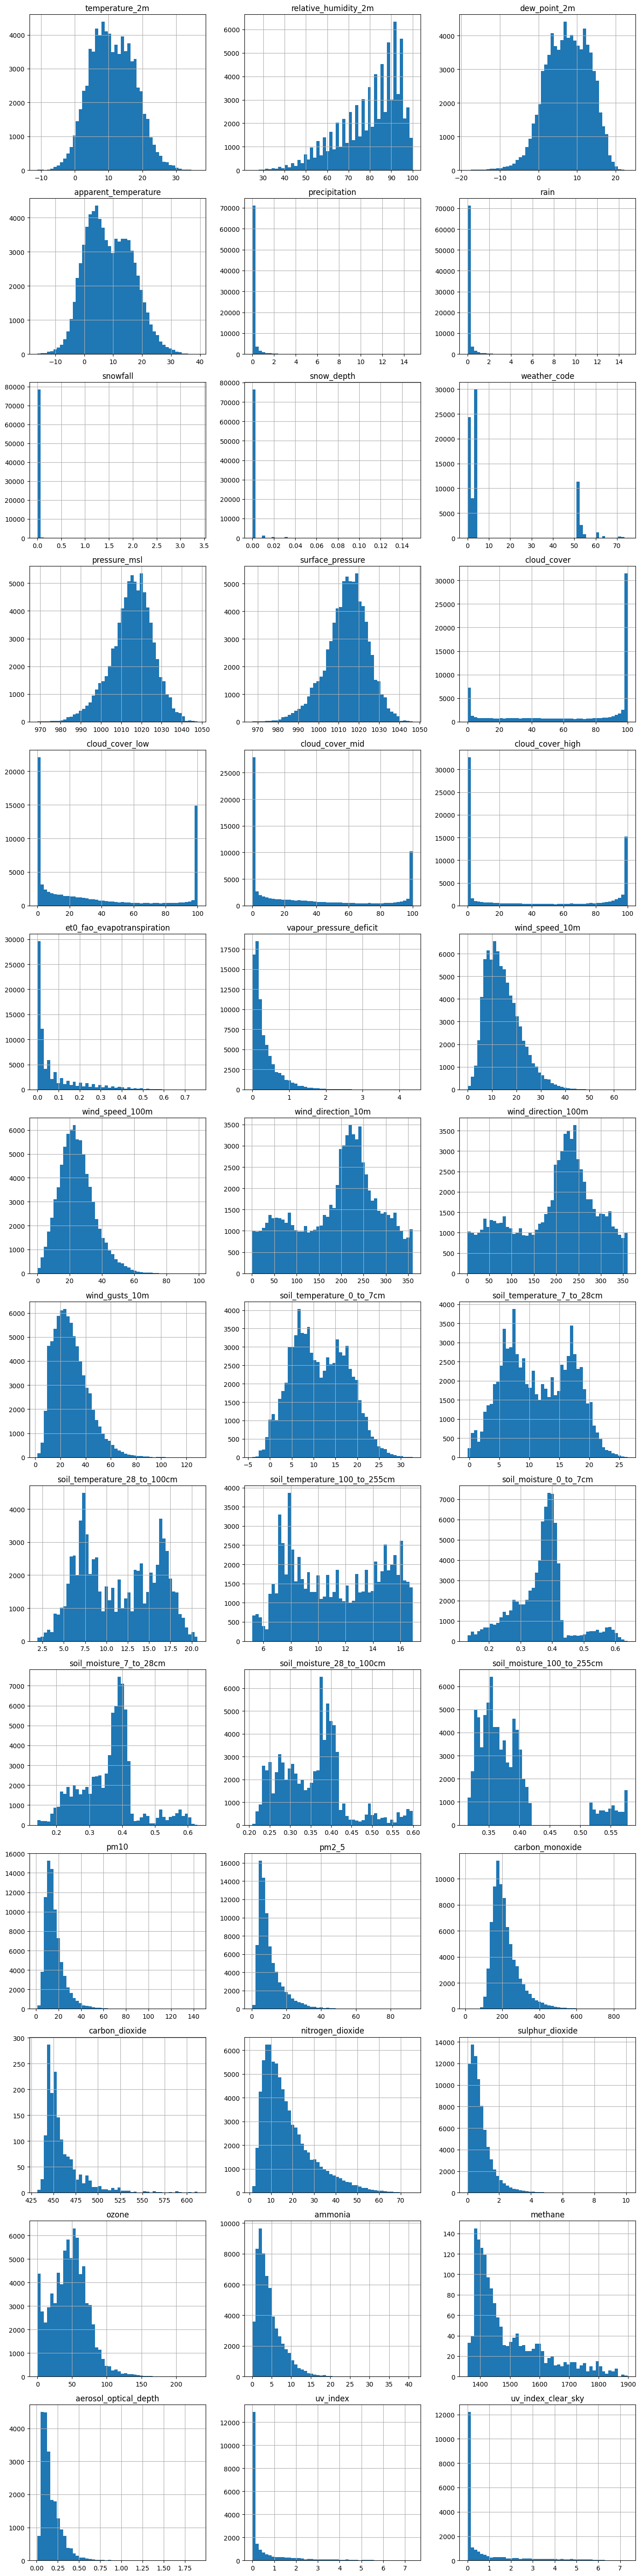

In [5]:
dist_summary = summarize_distributions(df)
plot_histograms(df)

### 4. Analyse correlations.

##### Feature Selection Summary for NO₂ Forecast Model

| Feature                                  | KEEP / DROP          | Reason                                               |
| ---------------------------------------- | -------------------- | ---------------------------------------------------- |
| **nitrogen_dioxide**                     | **KEEP**             | Target variable                                      |
| **pm10, pm2_5**                          | **KEEP**             | Strong co-pollutants from traffic and combustion     |
| **carbon_monoxide**                      | **KEEP**             | Traffic tracer, improves NO₂ prediction              |
| **ozone**                                | **KEEP**             | Photochemical counterpart; anti-correlated with NO₂  |
| **sulphur_dioxide**                      | **KEEP**             | Industrial emission marker; episodic signal          |
| **ammonia**, **aerosol_optical_depth**, **uv_index**, **uv_index_clear_sky**, **carbon_dioxide, methane**             | **DROP**             | Data incomplete, mostly missing values             |
| **temperature_2m**                       | **KEEP**             | Key thermodynamic driver                             |
| **apparent_temperature**                 | **DROP**             | Redundant with temperature + dew point               |
| **dew_point_2m**                         | **KEEP**             | Absolute humidity signal                             |
| **relative_humidity_2m**                 | **KEEP**             | Complements dew point via saturation %               |
| **soil_temperature***                    | **DROP**             | Slow-varying, irrelevant to NO₂                      |
| **soil_moisture***                       | **DROP**             | Same – no mechanistic relevance                      |
| **wind_speed_10m**                       | **KEEP**             | Main pollutant dispersion driver                     |
| **wind_direction_10m**                   | **KEEP (TRANSFORM)** | Encode as sin/cos to avoid circularity               |
| **wind_speed_100m, wind_direction_100m** | **DROP**             | Less relevant for ground-level NO₂                   |
| **wind_gusts_10m**                       | **KEEP**             | Adds turbulence information beyond speed             |
| **precipitation**                        | **KEEP**             | Governs pollutant washout                            |
| **rain**                                 | **DROP**             | Nearly identical to precipitation                    |
| **snowfall, snow_depth**                 | **DROP**             | Zero-dominant, no value in Utrecht                   |
| **cloud_cover_high**                     | **KEEP**             | Best predictor of radiation shielding affecting NO₂  |
| **cloud_cover, low, mid**                | **DROP**             | Less predictive, redundant                           |
| **pressure_msl**                         | **KEEP**             | Standardized pressure, relates to inversion trapping |
| **surface_pressure**                     | **DROP**             | Duplicate of pressure_msl                            |
| **weather_code**                         | **DROP**             | Categorical, already encoded via continuous vars     |
| **vapour_pressure_deficit**              | **KEEP**             | Key drying / thermodynamic driver                    |
| **et0_fao_evapotranspiration**           | **KEEP**             | Different physical process than VPD, complementary   |


=== Pearson correlation matrix (numeric features) ===
                               temperature_2m  relative_humidity_2m  \
temperature_2m                       1.000000             -0.477363   
relative_humidity_2m                -0.477363              1.000000   
dew_point_2m                         0.890738             -0.032041   
apparent_temperature                 0.986151             -0.391049   
precipitation                        0.012726              0.148422   
rain                                 0.025529              0.146219   
snowfall                            -0.084459              0.030341   
snow_depth                          -0.212423              0.026311   
weather_code                        -0.005627              0.173617   
pressure_msl                        -0.047017             -0.091315   
surface_pressure                    -0.044709             -0.092309   
cloud_cover                         -0.052898              0.209563   
cloud_cover_low        

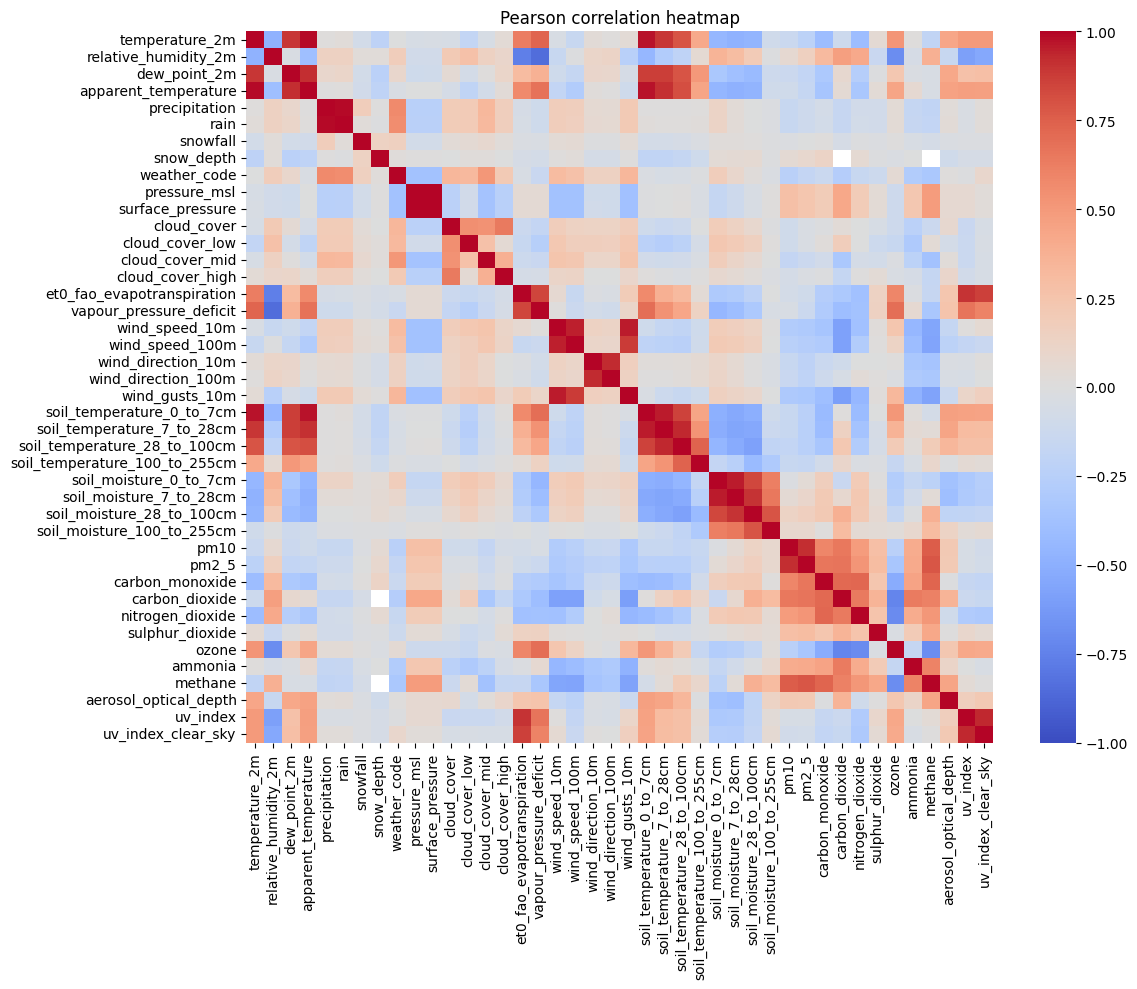

=== Pearson correlations with target 'nitrogen_dioxide' ===
carbon_monoxide                  0.724042
ozone                           -0.695935
carbon_dioxide                   0.643241
pm2_5                            0.520527
methane                          0.513497
pm10                             0.486508
wind_gusts_10m                  -0.447091
soil_temperature_0_to_7cm       -0.418897
relative_humidity_2m             0.417607
temperature_2m                  -0.409205
ammonia                          0.402966
wind_speed_10m                  -0.380901
et0_fao_evapotranspiration      -0.378163
vapour_pressure_deficit         -0.373915
soil_temperature_7_to_28cm      -0.361460
apparent_temperature            -0.333670
uv_index_clear_sky              -0.310336
uv_index                        -0.296431
soil_temperature_28_to_100cm    -0.287809
wind_speed_100m                 -0.285581
dew_point_2m                    -0.262392
sulphur_dioxide                  0.254298
soil_moisture_7_

In [6]:
corr_matrix = compute_correlation_matrix(df)
plot_correlation_heatmap(df)
corr_with_no2 = correlations_with_target(df, target_col="nitrogen_dioxide")

### 5. Explore temporal patterns (hourly and daily).

##### Diurnal Profile (Mean per Hour of Day)
| Feature                              | Behavior                                                            | Interpretation                                                                                                 |
| ------------------------------------ | ------------------------------------------------------------------- | -------------------------------------------------------------------------------------------------------------- |
| **NO₂**                              | Clear **double-peak** pattern – morning (~8 AM) and evening (~8 PM) | Classic traffic signature due to commute times. Strong diurnal structure  |
| **PM10, PM2.5**                      | Mild diurnal variability with afternoon peaks                       | Secondary formation during warm hours + slower peak from activities (e.g. heating, road dust).                 |
| **Ozone**                            | Inverse to NO₂: **lowest in early morning**, peaks at **14–17h**    | Photochemical formation tied to sunlight; confirms that UV and temperature drive chemistry.                    |
| **CO**                               | Tracks NO₂ but more muted variations                                | Traffic pattern as well, but lower volatility as CO disperses slower.                                          |
| **Sulfur dioxide**          | Minor variation                                                     | Weak diurnal drivers – likely dominated by background sources.                                                 |
| **Temperature, dew point, humidity** | Temperature: rises to afternoon peak; Humidity: inversely follows   | Perfect cyclic structure. Both relevant for predicting atmospheric stability and reaction rates.               |
| **Wind speed and gusts**             | Increases through day, peaks in afternoon                           | Typical boundary-layer behavior; daytime mixing reduces pollution after morning peaks.                         |
| **Cloud cover high**                 | Slightly higher at night, moderate during day                       | Good indicator of radiation blocking.            |
| **VPD & ET₀**                        | Both rise sharply midday and fall at night                          | Confirm complementarity: VPD measures moisture deficit; ET₀ captures evaporative power.                        |

##### Weekly Profile (Mean per Day, Mon–Sun)
| Feature                         | Behavior                                         | Interpretation                                                                   |
| ------------------------------- | ------------------------------------------------ | -------------------------------------------------------------------------------- |
| **NO₂**                         | Highest midweek (Tue–Thu), decreases on weekends | Classic weekday traffic effect – confirms needing weekly context.                |
| **Ozone**                       | Opposite trend: higher on weekends               | “Weekend ozone effect” – lower NOₓ allows more ozone formation. Well documented. |
| **CO, PM2.5, PM10**             | Slight midweek peaks                             | Follows NO₂: traffic and combustion sources.                                     |
| **Temperature, wind, humidity** | No consistent weekly cycle                       | Meteorology doesn't track weekly patterns – seasonal drivers dominate.           |
| **Cloud cover high**  | No weekly pattern                                | Expected because cloud cover and sunlight aren't human-driven.                   |

We add cyclical time features (hour and day encodings) because the temporal profiles reveal strong diurnal and weekly patterns in pollutant concentrations that the model would otherwise need to learn implicitly, requiring longer context windows and more data.


In [7]:
kept_features = [
    # Target
    "nitrogen_dioxide",

    # Co-pollutants
    "pm10",
    "pm2_5",
    "carbon_monoxide",
    "ozone",
    "sulphur_dioxide",

    # Meteorological variables
    "temperature_2m",
    "dew_point_2m",
    "relative_humidity_2m",
    "wind_speed_10m",
    "wind_gusts_10m",
    "wind_direction_10m",

    # Hydrological and radiative
    "precipitation",
    "cloud_cover_high",
    "pressure_msl",
    "vapour_pressure_deficit",
    "et0_fao_evapotranspiration"
]


diurnal = diurnal_profile(df, time_col="time", cols=kept_features)
weekly = weekly_profile(df, time_col="time", cols=kept_features)

=== Diurnal profile (mean by hour of day) ===
      nitrogen_dioxide       pm10      pm2_5  carbon_monoxide      ozone  \
hour                                                                       
0            19.688352  16.855566  10.781995       222.918771  40.772810   
1            18.143066  16.749361  10.977068       214.918796  40.125608   
2            17.084033  16.636071  10.999513       209.754258  39.164538   
3            16.286375  16.454106  10.879440       204.983273  38.561131   
4            15.912622  16.323114  10.843461       201.684915  37.378650   
5            16.295529  16.284337  10.829714       201.495134  36.072080   
6            18.187013  16.437226  10.955991       208.045012  33.997567   
7            20.957482  16.696290  11.240724       222.998479  32.423662   
8            21.957026  16.741545  11.346381       233.772506  33.902372   
9            20.758273  16.494039  11.338504       232.395681  38.013990   
10           18.498418  16.100943  11.1291

### 6. Detect and interpret outliers.

The detected outliers primarily reflect meaningful, real-world conditions (e.g., extreme weather events or pollution episodes) rather than data errors, so no feature removal or aggressive clipping is warranted at this stage.

In [8]:
# 5. Anomalies
kept_features = [
    # Target
    "nitrogen_dioxide",

    # Co-pollutants
    "pm10",
    "pm2_5",
    "carbon_monoxide",
    "ozone",
    "sulphur_dioxide",
    "ammonia",
    "aerosol_optical_depth",

    # Meteorological variables
    "temperature_2m",
    "dew_point_2m",
    "relative_humidity_2m",
    "wind_speed_10m",
    "wind_gusts_10m",
    "wind_direction_10m",

    # Hydrological and radiative
    "precipitation",
    "cloud_cover_high",
    "pressure_msl",
    "uv_index",
    "vapour_pressure_deficit",
    "et0_fao_evapotranspiration"
]

z_outliers = detect_outliers_zscore(df, cols=kept_features, z_thresh=3.0)
iqr_outliers = detect_outliers_iqr(df, cols=kept_features, iqr_multiplier=1.5)


=== Z-score Outlier Summary (threshold = 3.0) ===
                            n_outliers  pct_outliers
et0_fao_evapotranspiration        1732          2.19
vapour_pressure_deficit           1591          2.02
precipitation                     1560          1.98
pm2_5                             1490          1.89
sulphur_dioxide                   1491          1.89
pm10                              1428          1.81
carbon_monoxide                   1332          1.69
nitrogen_dioxide                  1081          1.37
ammonia                            930          1.18
wind_gusts_10m                     698          0.88
wind_speed_10m                     678          0.86
uv_index                           666          0.84
ozone                              617          0.78
relative_humidity_2m               454          0.58
pressure_msl                       404          0.51
dew_point_2m                       327          0.41
aerosol_optical_depth              319          